In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

This should be added to the final pre-processing step

In [49]:
path = "/work/PENPAL/PENPAL_analysis/data/TEXT/interim/interaction_level_stories_filtered.csv"
d = pd.read_csv(path)
path = "/work/PENPAL/PENPAL_analysis/data/TEXT/interim/stories_full_text_filtered.csv"
c = pd.read_csv(path)

In [50]:
d

,timestamp,user,ai,conversation_id,respondent_id,interaction_count,llm_type,starter
0,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,1.0,3,user
1,2025-11-13 12:36:05.046000+00:00,who claimed they loved her. This made her hard...,to take a chance and start attending social ev...,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,2.0,3,user
2,2025-11-13 12:37:38.170000+00:00,that she meet another young woman just like he...,"until one evening, when they both found themse...",conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,3.0,3,user
3,2025-11-13 12:39:04.145000+00:00,as if they where destined to meet. They starte...,"developed a deep and meaningful connection, on...",conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,4.0,3,user
4,2025-11-13 12:40:11.365000+00:00,time whent on their connection became more tha...,had been afraid to acknowledge the true nature...,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,5.0,3,user
...,...,...,...,...,...,...,...,...
685,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,6.0,4,ai
686,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,7.0,4,ai
687,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,8.0,4,ai
688,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,9.0,4,ai


In [51]:
c

,conversation_id,full_user,full_ai,timestamp,respondent_id,starter,llm_type,full_story
0,conv_006cb479-ccd3-40d1-83fb-4b614573f636,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",2025-11-13 12:34:34.539000+00:00,A89X12UN9Y1T,user,3,This is the story of\n\nThere once was a young...
1,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,"She looked at the dark sea, waiting for sign ...",This is the story of a lighthouse keeper who f...,2025-11-11 16:09:45.732000+00:00,4MY88EZZ8LCW,ai,2,This is the story of a lighthouse keeper who ...
2,conv_0bb56093-3033-4615-bb70-ebfa4135589a,"This is the story of\n\nJohn Cena, the famous ...","misinterpreted as ""Let's do this,"" but only hi...",2025-11-06 12:16:16.855000+00:00,VHE1FW23AMCW,user,3,"This is the story of\n\nJohn Cena, the famous ..."
3,conv_0f18b30f-7d4b-4681-b98e-a0ff4f2b5256,This is the story of\n\na small town girl who ...,She feels trapped in the mundane routine of he...,2025-11-10 19:27:13.854000+00:00,HY53S2L3H43F,user,3,This is the story of\n\na small town girl who ...
4,conv_11293fd2-d757-471f-8e2e-783542167a8e,"This is the story of\n\nA young girl, riding h...","in the sight before her. The object, which had...",2025-11-18 08:40:17.914000+00:00,L9SW1MM65H9W,user,3,"This is the story of\n\nA young girl, riding h..."
...,...,...,...,...,...,...,...,...
64,conv_da1c7ee9-2479-4f47-94bc-db9161a6e88c,This is the story of\n\nWhat does it mean to b...,depth and layers I hadn't considered before. T...,2025-11-18 11:10:56.683000+00:00,QJWLS13T5H1W,user,4,This is the story of\n\nWhat does it mean to b...
65,conv_e335739c-0072-4945-8fe4-457a04c0997b,This is the story of\n\nOnce upon a time there...,"to the diamond mine, their joyful voices echoi...",2025-11-11 17:17:20.655000+00:00,461W5T16XQ9W,user,3,This is the story of\n\nOnce upon a time there...
66,conv_e73d720a-ff86-4c9b-b988-d6cc879215d9,all the way to the top of the light house. an...,This is the story of a lighthouse keeper who s...,2025-11-17 12:12:24.650000+00:00,9UHVH9XRLD9F,ai,2,This is the story of a lighthouse keeper who ...
67,conv_f5028a6e-05a3-4757-84d0-491a6f400c24,everybody kept to themselves and did their jo...,"This is the story of a young girl named Ava, w...",2025-11-17 11:35:33.379000+00:00,HXFHNH63LZCS,ai,3,"This is the story of a young girl named Ava, ..."


In [47]:
c.loc[:,'full_story'][1]

' This is the story of a lighthouse keeper who forgot how to sleep.\n\nMara had tended the beacon on Skellig Point for seven years, watching ships pass She looked at the dark sea, waiting for sign of movement that was coming closer. One night a large cruiseline lit up the night. She almost felt blinded by the thousand glowing portholes, each one a tiny world of laughter and music drifting across the water. The vessel moved like a floating city, imposs impossible to miss. Usually the water was calm, only a handful of ships passing by. This was not usual. Even the lights were glimmering strangely—pulsing in rhythms that didn\'t match the waves. Mara pressed her face against the cold glass of the lighthouse gallery, her breath fo foggy in the chill night air. Without knowing why she grabbed the flashlight from the table and put the red lights on it, pointing it toward the ship. From one of the upper decks, an answering flash—red, then red again, then darkness. Her heart quickened. In seve

### EngSent

In [13]:

MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [14]:
def get_sentiment_scores(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "neg": np.nan, 
            "neu": np.nan, 
            "pos": np.nan, 
            "valence": np.nan,
            "label": None
        }

    # Tokenize
    inputs = tokenizer(text, return_tensors='pt', truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).flatten().cpu().numpy()

    neg, neu, pos = probs

    # continuous valence score
    valence = float(pos - neg)

    # discrete label
    label_id = int(np.argmax(probs))
    label_map = {0: "negative", 1: "neutral", 2: "positive"}
    label = label_map[label_id]

    return {
        "neg": float(neg),
        "neu": float(neu),
        "pos": float(pos),
        "valence": valence,
        "label": label,
    }


In [15]:

# Expand dictionary into multiple columns
print("Getting user sentiment")
df_user_sent = df['user'].apply(get_sentiment_scores).apply(pd.Series)
print("Getting ai sentiment")
df_ai_sent   = df['ai'].apply(get_sentiment_scores).apply(pd.Series)
print("Finalizing")
# Add suffixes to columns so nothing clashes
df_user_sent = df_user_sent.add_prefix('user_')
df_ai_sent   = df_ai_sent.add_prefix('ai_')

# Merge into original df
df = pd.concat([df, df_user_sent, df_ai_sent], axis=1)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Getting user sentiment
Getting ai sentiment
Finalizing


In [16]:
df.to_parquet('df_interaction_w_sent.parquet')

In [40]:
df[df['starter'] =='ai']

,timestamp,user,ai,combined_prompt,client_id,workshop_id,language,conversation_id,respondent_id,user_embedding,...,user_neg,user_neu,user_pos,user_valence,user_label,ai_neg,ai_neu,ai_pos,ai_valence,ai_label
13,2025-11-11 16:09:45.732000+00:00,This is the story of,a lighthouse keeper who forgot how to sleep.\n...,NaN,NaN,NaN,NaN,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,"[0.005245348438620567, 0.0015248586423695087, ...",...,0.026106,0.841248,0.132647,0.106541,neutral,0.519490,0.454280,0.026230,-0.493259,negative
14,2025-11-11 16:12:59.933000+00:00,"She looked at the dark sea, waiting for sign o...","by the thousand glowing portholes, each one a ...",NaN,NaN,NaN,NaN,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,"[0.0031612643506377935, -0.0010061485227197409...",...,0.100243,0.803425,0.096332,-0.003912,neutral,0.013436,0.437109,0.549455,0.536019,positive
15,2025-11-11 16:15:17.707000+00:00,impossible to miss. Usually the water was calm...,strangely—pulsing in rhythms that didn't match...,NaN,NaN,NaN,NaN,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,"[-0.003465140936896205, -0.015578682534396648,...",...,0.057039,0.501531,0.441430,0.384391,neutral,0.258025,0.716710,0.025265,-0.232760,neutral
16,2025-11-11 16:18:12.806000+00:00,foggy in the chill night air. Without knowing ...,"of the upper decks, an answering flash—red, th...",NaN,NaN,NaN,NaN,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,"[0.0053885625675320625, -0.0007463332731276751...",...,0.173376,0.795835,0.030789,-0.142587,neutral,0.247971,0.688773,0.063256,-0.184715,neutral
17,2025-11-11 16:20:10.304000+00:00,"her, when she flashed the red lights. Lighthou...","a sealed letter marked ""Open only when the red...",NaN,NaN,NaN,NaN,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,"[-0.007330004125833511, 0.0006138859898783267,...",...,0.051577,0.828776,0.119647,0.068070,neutral,0.014933,0.761915,0.223152,0.208219,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.013003706932067871, 0.00976136326789856, 0...",...,0.655431,0.325442,0.019127,-0.636305,negative,0.027035,0.602675,0.370290,0.343254,neutral
459,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.0008603244205005467, -0.002290817676112055...",...,0.274867,0.623917,0.101216,-0.173651,neutral,0.056795,0.727458,0.215747,0.158953,neutral
460,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.005458412226289511, 0.015171225182712078, ...",...,0.018699,0.316654,0.664647,0.645948,positive,0.005279,0.178763,0.815958,0.810678,positive
461,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.007142434362322092, 0.0070573207922279835,...",...,0.022350,0.496304,0.481346,0.458996,neutral,0.003330,0.143806,0.852865,0.849535,positive


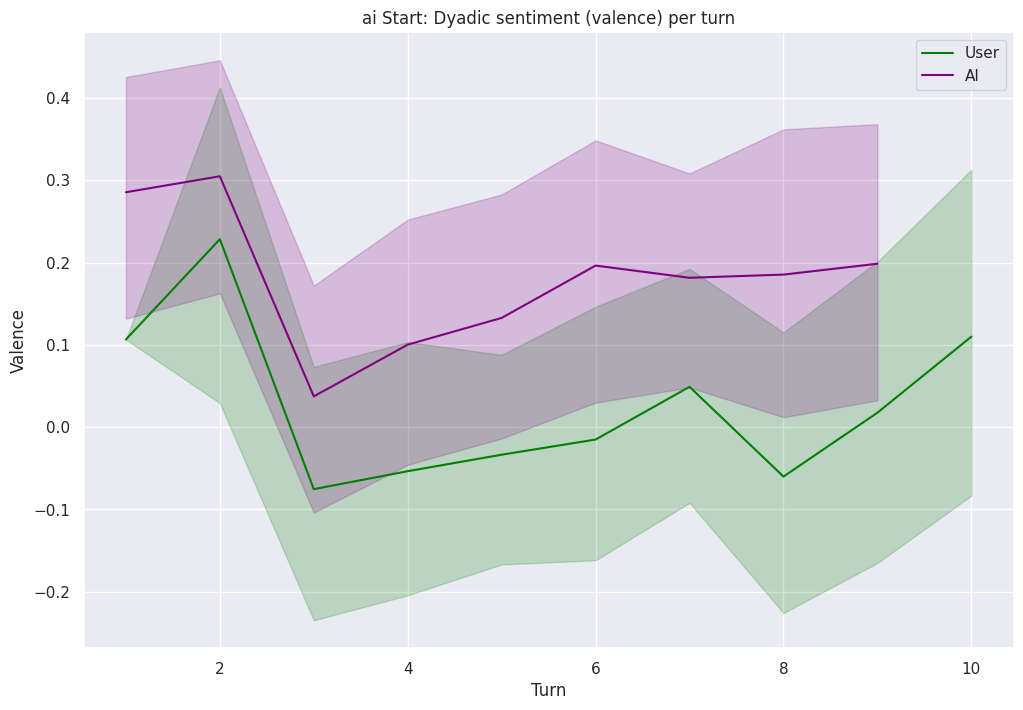

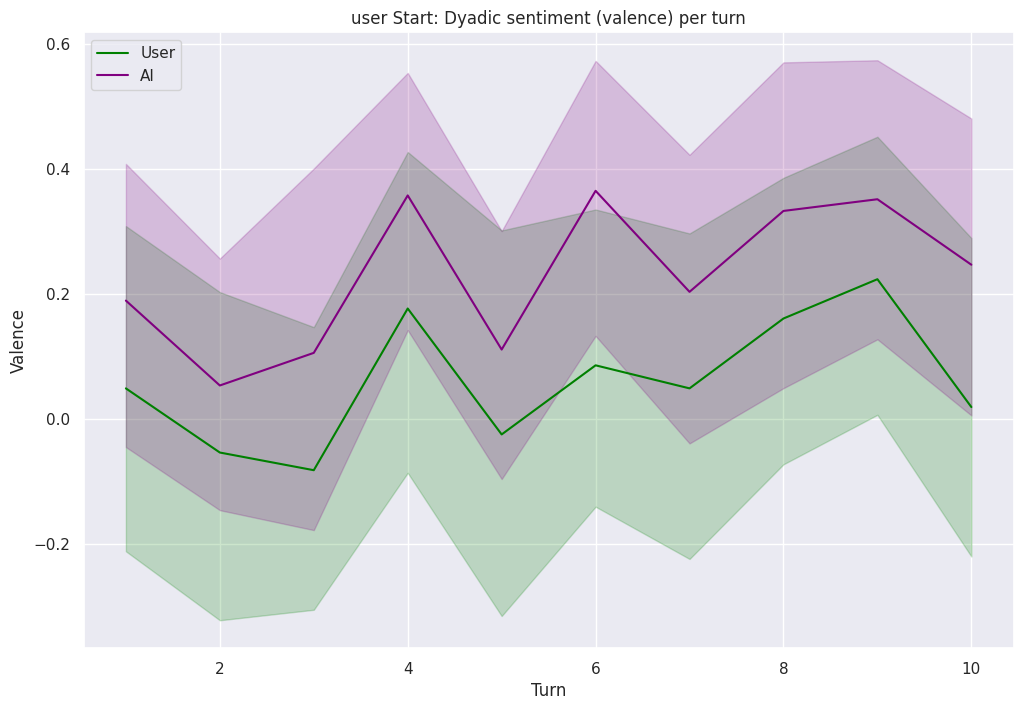

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

starters = ['ai', 'user']
sns.set_theme(style="darkgrid")

for s in starters: 
    plt.figure(figsize=(12, 8))
    df_ = df[df['starter'] == s]
    sns.lineplot(x="turn", y="user_valence", data=df_, label="User", color="green")
    sns.lineplot(x="turn", y="ai_valence", data=df_, label="AI", color="purple")

    plt.title(f"{s} Start: Dyadic sentiment (valence) per turn")
    plt.xlabel("Turn")
    plt.ylabel("Valence")
    plt.legend()
    plt.show()


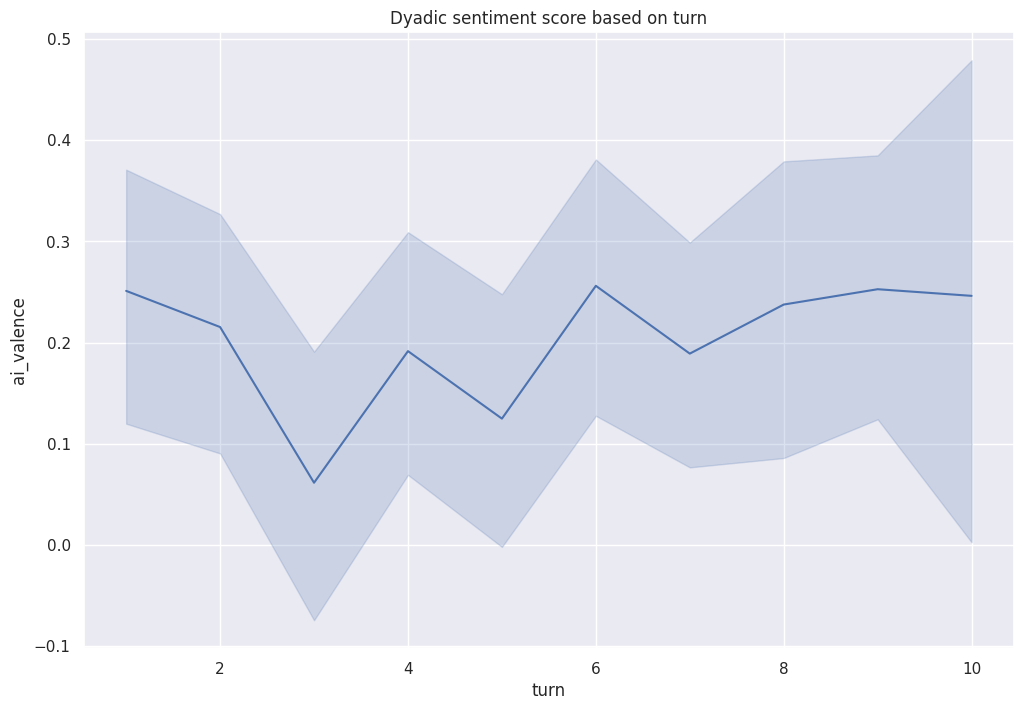

In [27]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.set_theme(style="darkgrid")
# Load an example dataset with long-form data

# Plot the responses for different events and regions
sns.lineplot(x="turn", y="ai_valence", data=df)
             
plt.title('Dyadic sentiment score based on turn')
plt.show()